# CropSmart — NAFSI Track 1: Predictive Modeling for Agricultural Resilience

## 1. Introduction

Agriculture in the United States faces growing threats from climate variability, including shifting precipitation patterns, increased drought frequency, and unpredictable growing seasons. This challenge uses **CropSmart**, a digital twin of real-world cropping systems over the Contiguous US (CONUS), to advance agricultural monitoring and resilience.

In this challenge, you will work with three operational geospatial datasets to analyze vegetation dynamics, detect crop rotation patterns, quantify soil moisture anomalies, and build predictive models for crop type classification.

---

### Datasets

| Dataset | Description | Resolution | Period | Link |
|---|---|---|---|---|
| **Cropland Data Layer (CDL)** | Annual crop type classification for CONUS, produced by USDA NASS. Includes 100+ crop and land cover categories. | 30 m | 2008–2025 | https://croplandcros.scinet.usda.gov/ https://nassgeodata.gmu.edu/CropScape/ |
| **Vegetation Index (NDVI)** | Daily and weekly composite NDVI derived from MODIS. Captures crop phenology and greenness dynamics. | 250 m | 2000–2026 | https://cloud.csiss.gmu.edu/CropSmart/ |
| **Soil Moisture (SMAP)** | Daily and weekly surface soil moisture estimates from NASA's Soil Moisture Active Passive mission. | 9 km | 2015–2025 | https://cloud.csiss.gmu.edu/CropSmart/ |

---

### CropSmart Web Services

You may use **CropSmart map and geoprocessing services** to access and process these datasets as needed. CropSmart provides WMS (Web Map Service) and WPS (Web Processing Service) endpoints for all three datasets.

> **Documentation:** [https://cloud.csiss.gmu.edu/CropSmart-documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation)

Refer to the documentation for available layers, service endpoints, spatial/temporal parameters, and example requests. The introduction section below demonstrates how to fetch and display data using the WMS interface.

### Get Data via WMS/WPS

The following cells demonstrate how to request and display map images from the CropSmart web services. Each map covers the full CONUS extent in the EPSG:5070 (Albers Equal Area) projection.

In [2]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
def fetch_wms_image(url):
    """Fetch a map image from a WMS endpoint and return a PIL Image."""
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGBA")

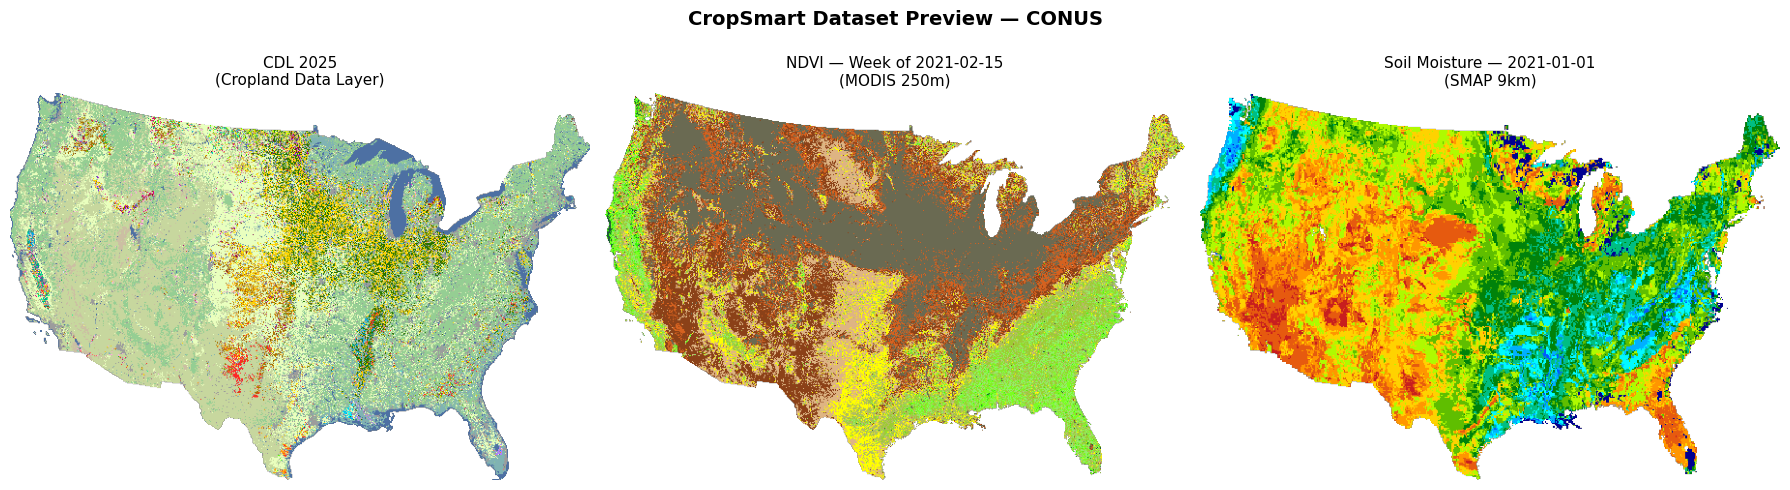

In [4]:
# WMS endpoints for the three datasets (CONUS extent, EPSG:5070)
wms_urls = {
    "CDL 2025\n(Cropland Data Layer)": (
        "https://nassgeodata.gmu.edu/CropScapeService/wms_cdlall.cgi"
        "?SERVICE=WMS&VERSION=1.1.1&REQUEST=GetMap"
        "&LAYERS=cdl_2025&TRANSPARENT=true&SRS=EPSG:5070"
        "&BBOX=-2354935.721,311822.402,2256319.225,3165592.366"
        "&FORMAT=image/png&WIDTH=600&HEIGHT=400"
    ),
    "NDVI — Week of 2021-02-15\n(MODIS 250m)": (
        "https://cloud.csiss.gmu.edu/smap_server/cgi-bin/mapserv"
        "?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap"
        "&MAP=/WMS/NDVI-WEEKLY_2021.map"
        "&LAYERS=NDVI-WEEKLY_2021_07_2021.02.15_2021.02.21"
        "&CRS=EPSG%3A5070&FORMAT=image%2Fpng&TRANSPARENT=true"
        "&BBOX=-2354935.721,311822.402,2256319.225,3165592.366"
        "&WIDTH=600&HEIGHT=400"
    ),
    "Soil Moisture — 2021-01-01\n(SMAP 9km)": (
        "https://cloud.csiss.gmu.edu/smap_server/cgi-bin/mapserv"
        "?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap"
        "&MAP=/WMS/SMAP-9KM-DAILY-SUB_2021.map"
        "&LAYERS=SMAP-9KM-DAILY-SUB_2021.01.01_AVERAGE"
        "&CRS=EPSG%3A5070&FORMAT=image%2Fpng&TRANSPARENT=true"
        "&BBOX=-2354935.721,311822.402,2256319.225,3165592.366"
        "&WIDTH=600&HEIGHT=400"
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CropSmart Dataset Preview — CONUS", fontsize=14, fontweight="bold", y=1.02)

for ax, (title, url) in zip(axes, wms_urls.items()):
    img = fetch_wms_image(url)
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

Code example of getting the dataset through WPS.

In [5]:
url = 'https://cloud.csiss.gmu.edu/smap_service?service=WPS&version=1.0.0&request=Execute&identifier=GetFileByFips&DataInputs=layer=SMAP-9KM-DAILY-SUB_2020.01.01_013000;fips=06'

r = requests.get(url)

r.content

b'<?xml version="1.0" encoding="UTF-8"?>\n<wps:ExecuteResponse xmlns:wps="http://www.opengis.net/wps/1.0.0" xmlns:ows="http://www.opengis.net/ows/1.1" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.opengis.net/wps/1.0.0 ../wpsExecute_response.xsd" service="WPS" version="1.0.0" xml:lang="en-US" serviceInstance="http://localhost/pywps?request=GetCapabilities&amp;amp;service=WPS" statusLocation="">\n    <wps:Process wps:processVersion="None">\n        <ows:Identifier>GetFileByFips</ows:Identifier>\n        <ows:Title>GetFileByFips</ows:Title>\n        <ows:Abstract>Get the url of target data by fips</ows:Abstract>\n\t</wps:Process>\n    <wps:Status creationTime="2026-04-13T15:31:22Z">\n        <wps:ProcessSucceeded>PyWPS Process GetFileByFips finished</wps:ProcessSucceeded>\n\t</wps:Status>\n\t<wps:ProcessOutputs>\n\t\t<wps:Output>\n            <ows:Identifier>fileUrl</ows:Identifier>\n            <ows:Title>

In [6]:
# Verifying WPS endpoint works (matches template  GetFileByFips returns a TIF URL)
# The XML response contains:
#   <ows:Identifier>fileUrl</ows:Identifier>
#   <wps:LiteralData dataType='string'>https://...tif</wps:LiteralData>

url = ('https://cloud.csiss.gmu.edu/smap_service?service=WPS&version=1.0.0'
       '&request=Execute&identifier=GetFileByFips'
       '&DataInputs=layer=SMAP-9KM-DAILY-SUB_2020.01.01_013000;fips=06')

r = requests.get(url)
print('WPS status:', r.status_code)
# Show first 400 chars of XML to confirm fileUrl is present
import re
m = re.search(r'LiteralData[^>]*>([^<]+)', r.text)
if m:
    print('WPS file URL confirmed:', m.group(1))

WPS status: 200
WPS file URL confirmed: https://nassgeo.csiss.gmu.edu/smap_cache/byFips/SMAP-9KM-DAILY-SUB_2020.01.01_013000_FIPS_06.tif


In [7]:
# !pip install rioxarray
# !pip install scipy
# !pip install scikit-learn
# !pip install xgboost

import os, re, json, time, warnings, tempfile
import xml.etree.ElementTree as ET
from pathlib import Path
from datetime import date, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import requests
from tqdm import tqdm
from scipy.ndimage import uniform_filter

import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

In [8]:

warnings.filterwarnings("ignore")
np.random.seed(42)

# Cache dirs
CACHE = Path("cropsmart_cache")
for sub in ("cdl", "ndvi", "smap"):
    (CACHE / sub).mkdir(parents=True, exist_ok=True)

#  Constants
FIPS      = "19"      # Iowa
CDL_CORN  = 1
CDL_SOY   = 5
CDL_WHEAT = 24

WPS_BASE = "https://cloud.csiss.gmu.edu/smap_service"
CDL_API  = "https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile"

print("Imports OK. Cache:", CACHE.resolve())

Imports OK. Cache: /home/jovyan/work/goodfellas/cropsmart-template/cropsmart_cache


In [9]:
# ============================================================
#  DATA ACCESS LAYER  (WPS + CropScape only)
# ============================================================

WPS_NS = {
    "wps": "http://www.opengis.net/wps/1.0.0",
    "ows": "http://www.opengis.net/ows/1.1",
}

def parse_wps_file_url(xml_bytes: bytes):
    """
    Parse WPS ExecuteResponse and return the fileUrl string.
    Falls back to regex scan if XML parse fails.
    """
    try:
        root = ET.fromstring(xml_bytes)
        for output in root.findall(".//wps:Output", WPS_NS):
            ident = output.findtext("ows:Identifier", namespaces=WPS_NS)
            if ident and "fileUrl" in ident:
                literal = output.findtext(".//wps:LiteralData", namespaces=WPS_NS)
                if literal:
                    return literal.strip()
    except ET.ParseError:
        pass
    # Regex fallback
    raw = xml_bytes.decode("utf-8", errors="replace")
    m = re.search(r'https?://[^\s<>"]+\.tif', raw)
    return m.group(0) if m else None


def download(url: str, dest: Path, timeout: int = 120):
    """Download url to dest; skip if cached. Returns Path or None."""
    if dest.exists() and dest.stat().st_size > 1024:
        return dest
    try:
        r = requests.get(url, timeout=timeout, stream=True)
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(65536):
                f.write(chunk)
        return dest
    except Exception as e:
        print(f"  [DL] {dest.name}: {e}")
        return None


def get_cdl(year: int):
    """Download Iowa CDL TIF for `year` via CropScape. Returns Path or None."""
    dest = CACHE / "cdl" / f"cdl_{year}_iowa.tif"
    if dest.exists() and dest.stat().st_size > 1024:
        return dest
    try:
        r = requests.get(CDL_API, params={"year": year, "fips": FIPS}, timeout=60)
        r.raise_for_status()
        tif_url = None
        try:
            root = ET.fromstring(r.content)
            for tag in root.iter():
                if tag.text and "http" in str(tag.text) and ".tif" in str(tag.text):
                    tif_url = tag.text.strip()
                    break
        except ET.ParseError:
            pass
        if not tif_url:
            for ext in [".tif", ".zip"]:
                m = re.search(r'https?://[^\s<>"]+' + ext, r.text)
                if m:
                    tif_url = m.group(0)
                    break
        if not tif_url:
            print(f"  [CDL {year}] No URL found. Response: {r.text[:200]}")
            return None
        return download(tif_url, dest)
    except Exception as e:
        print(f"  [CDL {year}] {e}")
        return None


def wps_get_tif(layer: str, dest: Path, fips: str = FIPS):
    """
    Call WPS GetFileByFips -> get Iowa-clipped TIF URL -> download.
    This is the primary method for NDVI and SMAP rasters.
    """
    if dest.exists() and dest.stat().st_size > 1024:
        return dest
    params = (
        "?service=WPS&version=1.0.0&request=Execute"
        "&identifier=GetFileByFips"
        f"&DataInputs=layer={layer};fips={fips}"
    )
    try:
        r = requests.get(WPS_BASE + params, timeout=90)
        r.raise_for_status()
        url = parse_wps_file_url(r.content)
        if not url:
            print(f"  [WPS] No URL in response for {layer[:60]}")
            return None
        return download(url, dest)
    except Exception as e:
        print(f"  [WPS] {layer[:60]}: {e}")
        return None


def read_tif(path: Path):
    """Read band 1 as float32; nodata -> NaN. Returns (array, transform, crs)."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        return arr, src.transform, src.crs


def resample_to(src_path: Path, ref_shape, ref_transform, ref_crs,
                method=Resampling.nearest):
    """Reproject src_path to match ref_shape/transform/crs."""
    dest = np.empty(ref_shape, dtype=np.float32)
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=dest,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=method,
        )
        if src.nodata is not None:
            dest[dest == src.nodata] = np.nan
    return dest


def _week_dates(year: int, week: int):
    """Return (monday, sunday) for ISO week of year."""
    jan4 = date(year, 1, 4)
    monday = jan4 - timedelta(days=jan4.weekday()) + timedelta(weeks=week - 1)
    return monday, monday + timedelta(days=6)


def ndvi_layer(year: int, week: int) -> str:
    """Build NDVI-WEEKLY layer name per CropSmart naming convention."""
    m, s = _week_dates(year, week)
    return f"NDVI-WEEKLY_{year}_{week:02d}_{m.strftime('%Y.%m.%d')}_{s.strftime('%Y.%m.%d')}"


def smap_anomaly_layer(year: int, week: int) -> str:
    """Build SMAP-9KM-ANOMALY-WEEKLY-SUB layer name."""
    m, s = _week_dates(year, week)
    return (f"SMAP-9KM-ANOMALY-WEEKLY-SUB_{year}_{week:02d}_"
            f"{m.strftime('%Y.%m.%d')}_{s.strftime('%Y.%m.%d')}")


print("Data access layer ready.")
print(f"  NDVI example:  {ndvi_layer(2021, 26)}")
print(f"  SMAP example:  {smap_anomaly_layer(2019, 18)}")

Data access layer ready.
  NDVI example:  NDVI-WEEKLY_2021_26_2021.06.28_2021.07.04
  SMAP example:  SMAP-9KM-ANOMALY-WEEKLY-SUB_2019_18_2019.04.29_2019.05.05


---

## 2. Task 1 — NDVI Time Series Analysis by Crop Type

Using the MODIS NDVI product and the CDL as a crop type mask, extract and compare NDVI time series for **corn** and **soybean** pixels over the growing season within the study area of **U.S. Corn Belt** (e.g., Iowa, Nebraska). Your analysis should:

- Calculate mean and interquartile range of NDVI by crop type
- Visualize seasonal NDVI profiles (phenological curves) for corn vs. soybean, highlighting key growing stages (e.g., planting, green-up, peak greenness, and harvest)

**Expected output:** A figure comparing NDVI phenological curves for both crop types with uncertainty bands, and a brief interpretation of the drivers behind observed patterns.

> **Tip:** You can use the CropSmart WMS/WPS services to access CDL and NDVI layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [10]:
# Task 1 — Your code here
# T1.1: CDL 2021
print("Downloading CDL 2021...")
cdl21_path = get_cdl(2021)
assert cdl21_path, "CDL 2021 download failed"

cdl21, cdl_t21, cdl_c21 = read_tif(cdl21_path)
cdl21 = np.nan_to_num(cdl21, nan=0).astype(np.uint8)
H, W  = cdl21.shape
print(f"  CDL 2021: {H}x{W} px, CRS=EPSG:{cdl_c21.to_epsg()}")
print(f"  Corn: {(cdl21==CDL_CORN).sum():,}  |  Soy: {(cdl21==CDL_SOY).sum():,}")

  CDL 2021: 11671x17795 px, CRS=EPSG:5070
  Corn: 57,676,235  |  Soy: 45,641,047


In [11]:
# T1.2: Download NDVI weekly rasters via WPS GetFileByFips
NDVI_YEAR  = 2021
NDVI_WEEKS = list(range(14, 45))   # Apr -> Nov growing season

ndvi_paths = {}

def _fetch_ndvi(wk):
    layer = ndvi_layer(NDVI_YEAR, wk)
    dest  = CACHE / "ndvi" / f"ndvi_{NDVI_YEAR}_{wk:02d}.tif"
    return wk, wps_get_tif(layer, dest)

print(f"Downloading {len(NDVI_WEEKS)} NDVI weekly rasters (4 workers)...")
with ThreadPoolExecutor(max_workers=4) as ex:
    futs = {ex.submit(_fetch_ndvi, wk): wk for wk in NDVI_WEEKS}
    for f in tqdm(as_completed(futs), total=len(futs), desc="NDVI 2021"):
        wk, p = f.result()
        if p:
            ndvi_paths[wk] = p

weeks_ok = sorted(ndvi_paths.keys())
print(f"Downloaded: {len(weeks_ok)}/{len(NDVI_WEEKS)} weeks")

NDVI 2021: 100%|██████████| 31/31 [00:00<00:00, 4492.86it/s]

Downloaded: 31/31 weeks


In [12]:
# T1.3: Compute NDVI stats per crop type 
ref_path = ndvi_paths[weeks_ok[0]]
ref_arr, ref_transform, ref_crs = read_tif(ref_path)
ref_shape = ref_arr.shape
print(f"NDVI grid: {ref_shape}  (~{ref_shape[0]*250/1000:.0f}km x {ref_shape[1]*250/1000:.0f}km at 250m)")

# Resample CDL 30m -> 250m using mode (preserves dominant class)
print("Resampling CDL to NDVI 250m grid...")
cdl21_250 = resample_to(cdl21_path, ref_shape, ref_transform, ref_crs,
                        Resampling.mode).astype(np.uint8)

# Purity filter
# For each 250m cell, compute what fraction of the underlying 30m pixels
# are actually that crop. Only use cells where fraction > 0.60.
# This eliminates mixed-edge pixels that wash out corn/soy differences.
with rasterio.open(cdl21_path) as cdl_src:
    cdl_raw = cdl_src.read(1).astype(np.float32)

    corn_frac_250 = np.empty(ref_shape, dtype=np.float32)
    soy_frac_250  = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=(cdl_raw == CDL_CORN).astype(np.float32),
        destination=corn_frac_250,
        src_transform=cdl_src.transform, src_crs=cdl_src.crs,
        dst_transform=ref_transform,     dst_crs=ref_crs,
        resampling=Resampling.average,
    )
    reproject(
        source=(cdl_raw == CDL_SOY).astype(np.float32),
        destination=soy_frac_250,
        src_transform=cdl_src.transform, src_crs=cdl_src.crs,
        dst_transform=ref_transform,     dst_crs=ref_crs,
        resampling=Resampling.average,
    )

PURITY = 0.60
corn_mask = (cdl21_250 == CDL_CORN) & (corn_frac_250 > PURITY)
soy_mask  = (cdl21_250 == CDL_SOY)  & (soy_frac_250  > PURITY)

print(f"Pure corn pixels (>{PURITY*100:.0f}%): {corn_mask.sum():,}")
print(f"Pure soy  pixels (>{PURITY*100:.0f}%): {soy_mask.sum():,}")

# CropSmart encoding: raw = NDVI * 100 + 100  ->  NDVI = (raw - 100) / 100
# Allow slightly negative values (-0.05) to capture post-harvest bare fields
stats = []
for wk in weeks_ok:
    arr, _, _ = read_tif(ndvi_paths[wk])
    arr = (arr - 100.0) / 100.0
    arr[(arr < -0.05) | (arr > 1.0)] = np.nan   # -0.05 floor preserves harvest signal

    for crop_lbl, mask in [("Corn", corn_mask), ("Soy", soy_mask)]:
        vals = arr[mask]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 100:
            stats.append({
                "week": wk,
                "crop": crop_lbl,
                "mean": float(np.mean(vals)),
                "q25":  float(np.percentile(vals, 25)),
                "q75":  float(np.percentile(vals, 75)),
            })

df_ndvi = pd.DataFrame(stats)
print("\nPeak NDVI by crop:")
print(df_ndvi.groupby("crop")["mean"].max())
print("\nMin NDVI by crop (should show harvest decline):")
print(df_ndvi.groupby("crop")["mean"].min())

NDVI grid: (1399, 2134)  (~350km x 534km at 250m)
Resampling CDL to NDVI 250m grid...
Pure corn pixels (>60%): 719,385
Pure soy  pixels (>60%): 546,681

Peak NDVI by crop:
crop
Corn    0.948404
Soy     0.963208
Name: mean, dtype: float64

Min NDVI by crop (should show harvest decline):
crop
Corn    0.493063
Soy     0.489480
Name: mean, dtype: float64


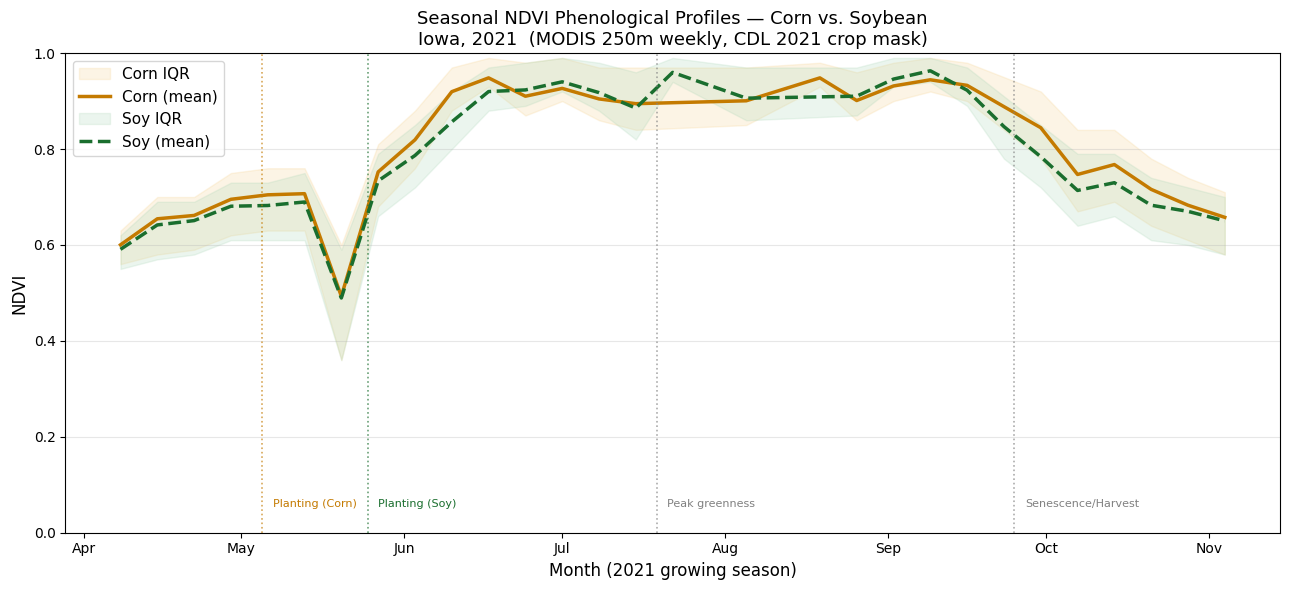

Saved: task1_ndvi_phenology.png


In [13]:
# T1.4: Phenological curve plot
fig, ax = plt.subplots(figsize=(13, 6))

def week_to_doy(yr, wk):
    mon, _ = _week_dates(yr, wk)
    return mon.timetuple().tm_yday + 3  # week midpoint

STYLES = {
    "Corn": {"color": "#c47a00", "fill": "#f5d08a", "ls": "-"},
    "Soy":  {"color": "#1a6e2e", "fill": "#a8d5b5", "ls": "--"},
}

for crop, st in STYLES.items():
    sub = df_ndvi[df_ndvi["crop"] == crop].sort_values("week")
    doy = [week_to_doy(NDVI_YEAR, w) for w in sub["week"]]
    ax.fill_between(doy, sub["q25"], sub["q75"], alpha=0.22,
                    color=st["fill"], label=f"{crop} IQR")
    ax.plot(doy, sub["mean"], color=st["color"], lw=2.5,
            ls=st["ls"], label=f"{crop} (mean)")

# Phenological stage markers
for doy_v, lbl, col in [
    (125, "Planting (Corn)",    "#c47a00"),
    (145, "Planting (Soy)",     "#1a6e2e"),
    (200, "Peak greenness",     "gray"),
    (268, "Senescence/Harvest", "gray"),
]:
    ax.axvline(doy_v, color=col, ls=":", lw=1.2, alpha=0.65)
    ax.text(doy_v + 2, 0.05, lbl, fontsize=8, color=col, va="bottom")

# Month x-axis
MONTHS = {"Apr": 91, "May": 121, "Jun": 152, "Jul": 182,
           "Aug": 213, "Sep": 244, "Oct": 274, "Nov": 305}
ax.set_xticks(list(MONTHS.values()))
ax.set_xticklabels(list(MONTHS.keys()), fontsize=10)
ax.set_ylabel("NDVI", fontsize=12)
ax.set_xlabel("Month (2021 growing season)", fontsize=12)
ax.set_title(
    "Seasonal NDVI Phenological Profiles — Corn vs. Soybean\n"
    "Iowa, 2021  (MODIS 250m weekly, CDL 2021 crop mask)",
    fontsize=13
)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("task1_ndvi_phenology.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task1_ndvi_phenology.png")

---

## 3. Task 2 — Crop Rotation Pattern Identification

Develop a method to identify parcels exhibiting **regular crop rotation** (e.g., corn-soybean annual alternation) using a **10-year CDL time series** over a Corn Belt study area. Your analysis should:

- Define a quantitative criterion for rotation regularity (e.g., alternating patterns, transition frequency)
- Classify pixels into rotation categories: regular rotation, continuous monoculture, and irregular cropping
- Map the spatial distribution of rotation patterns and compute areal statistics by class

**Expected output:** A classified rotation map, a summary table of areal statistics by rotation class, and a brief discussion of any observable spatial patterns.

> **Tip:** You can use the CropSmart WMS/WPS services to access multi-year CDL layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [14]:
# Task 2 — Your code here
# T2.1: Download CDL 2013–2022 
ROT_YEARS = list(range(2013, 2023))
cdl_paths = {}

for yr in ROT_YEARS:
    p = get_cdl(yr)
    if p:
        cdl_paths[yr] = p
        print(f"  CDL {yr}")
    else:
        print(f"  CDL {yr} FAILED")

print(f"\nLoaded {len(cdl_paths)}/10 CDL years")

  CDL 2013
  CDL 2014
  CDL 2015
  CDL 2016
  CDL 2017
  CDL 2018
  CDL 2019
  CDL 2020
  CDL 2021
  CDL 2022

Loaded 10/10 CDL years


In [15]:
# T2.2: Stack CDL to (10 x H x W)
cdl_stack = np.zeros((len(ROT_YEARS), H, W), dtype=np.uint8)

for i, yr in enumerate(tqdm(ROT_YEARS, desc="Stacking CDL")):
    if yr not in cdl_paths:
        continue
    if yr == 2021:
        cdl_stack[i] = cdl21  # already in memory
    else:
        with rasterio.open(cdl_paths[yr]) as src:
            if src.shape == (H, W) and src.transform == cdl_t21:
                cdl_stack[i] = src.read(1).astype(np.uint8)
            else:
                arr = resample_to(cdl_paths[yr], (H, W), cdl_t21, cdl_c21, Resampling.nearest)
                cdl_stack[i] = np.nan_to_num(arr, nan=0).astype(np.uint8)

print(f"CDL stack: {cdl_stack.shape}  dtype={cdl_stack.dtype}")

Stacking CDL: 100%|██████████| 10/10 [00:02<00:00,  4.58it/s]

CDL stack: (10, 11671, 17795)  dtype=uint8


In [16]:
#  T2.3: Classify rotation patterns
is_corn  = (cdl_stack == CDL_CORN)
is_soy   = (cdl_stack == CDL_SOY)

corn_yrs = is_corn.sum(axis=0).astype(np.uint8)
soy_yrs  = is_soy.sum(axis=0).astype(np.uint8)

# Count corn<->soy alternating transitions (9 consecutive year pairs)
alt = np.zeros((H, W), dtype=np.uint8)
for t in range(9):
    prev, curr = cdl_stack[t], cdl_stack[t + 1]
    alt += (((prev == CDL_CORN) & (curr == CDL_SOY)) |
            ((prev == CDL_SOY)  & (curr == CDL_CORN))).astype(np.uint8)

ever_crop = (is_corn | is_soy).any(axis=0)

rot_map = np.zeros((H, W), dtype=np.uint8)
m_reg   = ever_crop & (alt >= 7) & (corn_yrs >= 3) & (soy_yrs >= 3)
m_ccorn = ever_crop & ~m_reg & (corn_yrs >= 8)
m_csoy  = ever_crop & ~m_reg & ~m_ccorn & (soy_yrs >= 8)
m_irr   = ever_crop & ~m_reg & ~m_ccorn & ~m_csoy

rot_map[m_reg]   = 1
rot_map[m_ccorn] = 2
rot_map[m_csoy]  = 3
rot_map[m_irr]   = 4

HA = 0.09  # ha per 30m pixel
total_ha = float(ever_crop.sum()) * HA

rot_stats = pd.DataFrame([
    {"Class": "Regular Corn-Soy",  "Code": 1,
     "Area (ha)": round(m_reg.sum()   * HA), "% Cropland": round(100*m_reg.sum()   /ever_crop.sum(), 1)},
    {"Class": "Continuous Corn",   "Code": 2,
     "Area (ha)": round(m_ccorn.sum() * HA), "% Cropland": round(100*m_ccorn.sum() /ever_crop.sum(), 1)},
    {"Class": "Continuous Soybean","Code": 3,
     "Area (ha)": round(m_csoy.sum()  * HA), "% Cropland": round(100*m_csoy.sum()  /ever_crop.sum(), 1)},
    {"Class": "Irregular / Other", "Code": 4,
     "Area (ha)": round(m_irr.sum()   * HA), "% Cropland": round(100*m_irr.sum()   /ever_crop.sum(), 1)},
])

print(f"Total corn/soy cropland: {total_ha:,.0f} ha")
print()
print(rot_stats.to_string(index=False))

Total corn/soy cropland: 10,203,144 ha

             Class  Code  Area (ha)  % Cropland
  Regular Corn-Soy     1    6215738        60.9
   Continuous Corn     2    1056374        10.4
Continuous Soybean     3      20674         0.2
 Irregular / Other     4    2910359        28.5


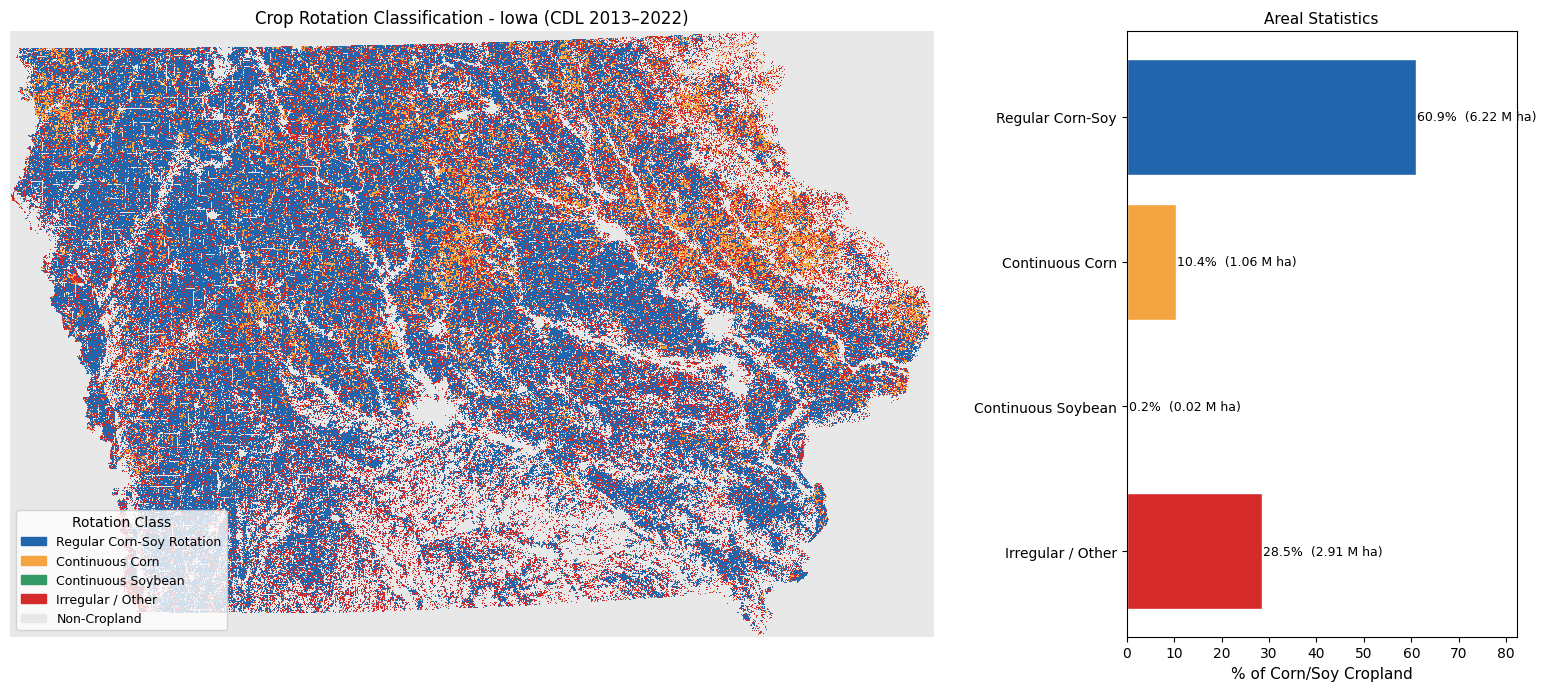

Saved: task2_rotation_map.png


In [17]:
# T2.4: Rotation map + areal stats 
fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(16, 7),
                                      gridspec_kw={"width_ratios": [2.5, 1]})

ROT_COLORS = ["#e8e8e8", "#2166ac", "#f4a541", "#339966", "#d62b2b"]
cmap_r = mcolors.ListedColormap(ROT_COLORS)
norm_r = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_r.N)

ax_map.imshow(rot_map, cmap=cmap_r, norm=norm_r, interpolation="none")
ax_map.set_title("Crop Rotation Classification - Iowa (CDL 2013–2022)", fontsize=12)
ax_map.axis("off")
ax_map.legend(handles=[
    mpatches.Patch(color="#2166ac", label="Regular Corn-Soy Rotation"),
    mpatches.Patch(color="#f4a541", label="Continuous Corn"),
    mpatches.Patch(color="#339966", label="Continuous Soybean"),
    mpatches.Patch(color="#d62b2b", label="Irregular / Other"),
    mpatches.Patch(color="#e8e8e8", edgecolor="gray", label="Non-Cropland"),
], loc="lower left", fontsize=9, title="Rotation Class")

bar_clr = ["#2166ac", "#f4a541", "#339966", "#d62b2b"]
bars = ax_bar.barh(rot_stats["Class"], rot_stats["% Cropland"],
                   color=bar_clr, edgecolor="white")
for bar, row in zip(bars, rot_stats.itertuples()):
    ax_bar.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{row._4:.1f}%  ({row._3/1e6:.2f} M ha)",
                va="center", fontsize=9)
ax_bar.set_xlabel("% of Corn/Soy Cropland", fontsize=11)
ax_bar.set_title("Areal Statistics", fontsize=11)
ax_bar.set_xlim(0, rot_stats["% Cropland"].max() * 1.35)
ax_bar.invert_yaxis()

plt.tight_layout()
plt.savefig("task2_rotation_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task2_rotation_map.png")

---

## 4. Task 3 — Soil Moisture Anomaly Calculation

Using the SMAP L4 soil moisture product, calculate **soil moisture anomalies** for a defined period of interest (e.g., the 2019 Midwest flooding, the 2022 Great Plains drought, or any multi-week window of your choice) and assess the agricultural impact using CDL crop masks. Your analysis should:

- Define a baseline climatology (e.g., multi-year mean and standard deviation per calendar day or week)
- Produce spatial anomaly maps relative to the baseline
- Identify the most severely affected crop-growing regions and connect the anomalies to potential agricultural impacts

**Expected output:** Spatial anomaly maps, time series of area-averaged anomalies over cropland, and a brief interpretation linking soil moisture conditions to agricultural context.

> **Tip:** You can use the CropSmart WMS/WPS services to access SMAP and CDL layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [18]:
# Task 3 — Your code here
# T3.1: Download SMAP anomaly rasters + CDL 2019 
EVENT_YEAR = 2019
SMAP_WEEKS = list(range(12, 33))  # mid-March -> mid-August

smap_paths = {}

def _fetch_smap(wk):
    layer = smap_anomaly_layer(EVENT_YEAR, wk)
    dest  = CACHE / "smap" / f"smap_anom_{EVENT_YEAR}_{wk:02d}.tif"
    return wk, wps_get_tif(layer, dest)

print(f"Downloading {len(SMAP_WEEKS)} SMAP anomaly rasters...")
with ThreadPoolExecutor(max_workers=4) as ex:
    futs = {ex.submit(_fetch_smap, wk): wk for wk in SMAP_WEEKS}
    for f in tqdm(as_completed(futs), total=len(futs), desc="SMAP 2019"):
        wk, p = f.result()
        if p:
            smap_paths[wk] = p

print(f"SMAP: {len(smap_paths)}/{len(SMAP_WEEKS)} weeks OK")

print("Downloading CDL 2019...")
cdl19_path = get_cdl(EVENT_YEAR)
assert cdl19_path, "CDL 2019 failed"

SMAP 2019: 100%|██████████| 21/21 [00:00<00:00, 3671.39it/s]

SMAP: 21/21 weeks OK


In [19]:
# T3.2: Build cropland fraction mask at SMAP 9km 
# Resample CDL 30m binary crop mask -> 9km using average resampling
# Result: fraction of each 9km cell covered by corn or soy

smap_wks_ok = sorted(smap_paths.keys())
with rasterio.open(smap_paths[smap_wks_ok[0]]) as src:
    smap_shape = (src.height, src.width)
    smap_transform = src.transform
    smap_crs = src.crs

print(f"SMAP Iowa grid: {smap_shape}")

with rasterio.open(cdl19_path) as cdl_src:
    cdl19_raw = cdl_src.read(1).astype(np.float32)
    crop_bin = ((cdl19_raw == CDL_CORN) | (cdl19_raw == CDL_SOY)).astype(np.float32)

    crop_frac = np.empty(smap_shape, dtype=np.float32)
    reproject(
        source=crop_bin,
        destination=crop_frac,
        src_transform=cdl_src.transform,
        src_crs=cdl_src.crs,
        dst_transform=smap_transform,
        dst_crs=smap_crs,
        resampling=Resampling.average,
    )

# SMAP cells where >20% of area is corn/soy
crop_mask_9km = crop_frac > 0.20
print(f"Cropland-dominant cells (>20%): {crop_mask_9km.sum()} / {crop_frac.size}")

SMAP Iowa grid: (38, 59)
Cropland-dominant cells (>20%): 1695 / 2242


In [20]:
# T3.3: Area-averaged anomaly time series 
ts_rows = []
anom_stack = {}

for wk in smap_wks_ok:
    arr, _, _ = read_tif(smap_paths[wk])
    anom_stack[wk] = arr
    ts_rows.append({
        "week":     wk,
        "date":     _week_dates(EVENT_YEAR, wk)[0].strftime("%b %d"),
        "all_iowa": float(np.nanmean(arr)),
        "cropland": float(np.nanmean(arr[crop_mask_9km])),
    })

df_smap = pd.DataFrame(ts_rows)
print(df_smap[["week","date","cropland"]].to_string(index=False))

 week   date  cropland
   12 Mar 18  0.171638
   13 Mar 25  0.133247
   14 Apr 01  0.122199
   15 Apr 08  0.132380
   16 Apr 15  0.110938
   17 Apr 22  0.077747
   18 Apr 29  0.082201
   19 May 06  0.079537
   20 May 13  0.076941
   21 May 20  0.110813
   22 May 27  0.151006
   23 Jun 03  0.148202
   24 Jun 10  0.115020
   25 Jun 17  0.137979
   26 Jun 24  0.135545
   27 Jul 01  0.129767
   28 Jul 08  0.104165
   29 Jul 15  0.108476
   30 Jul 22  0.109117
   31 Jul 29  0.097674
   32 Aug 05  0.063216


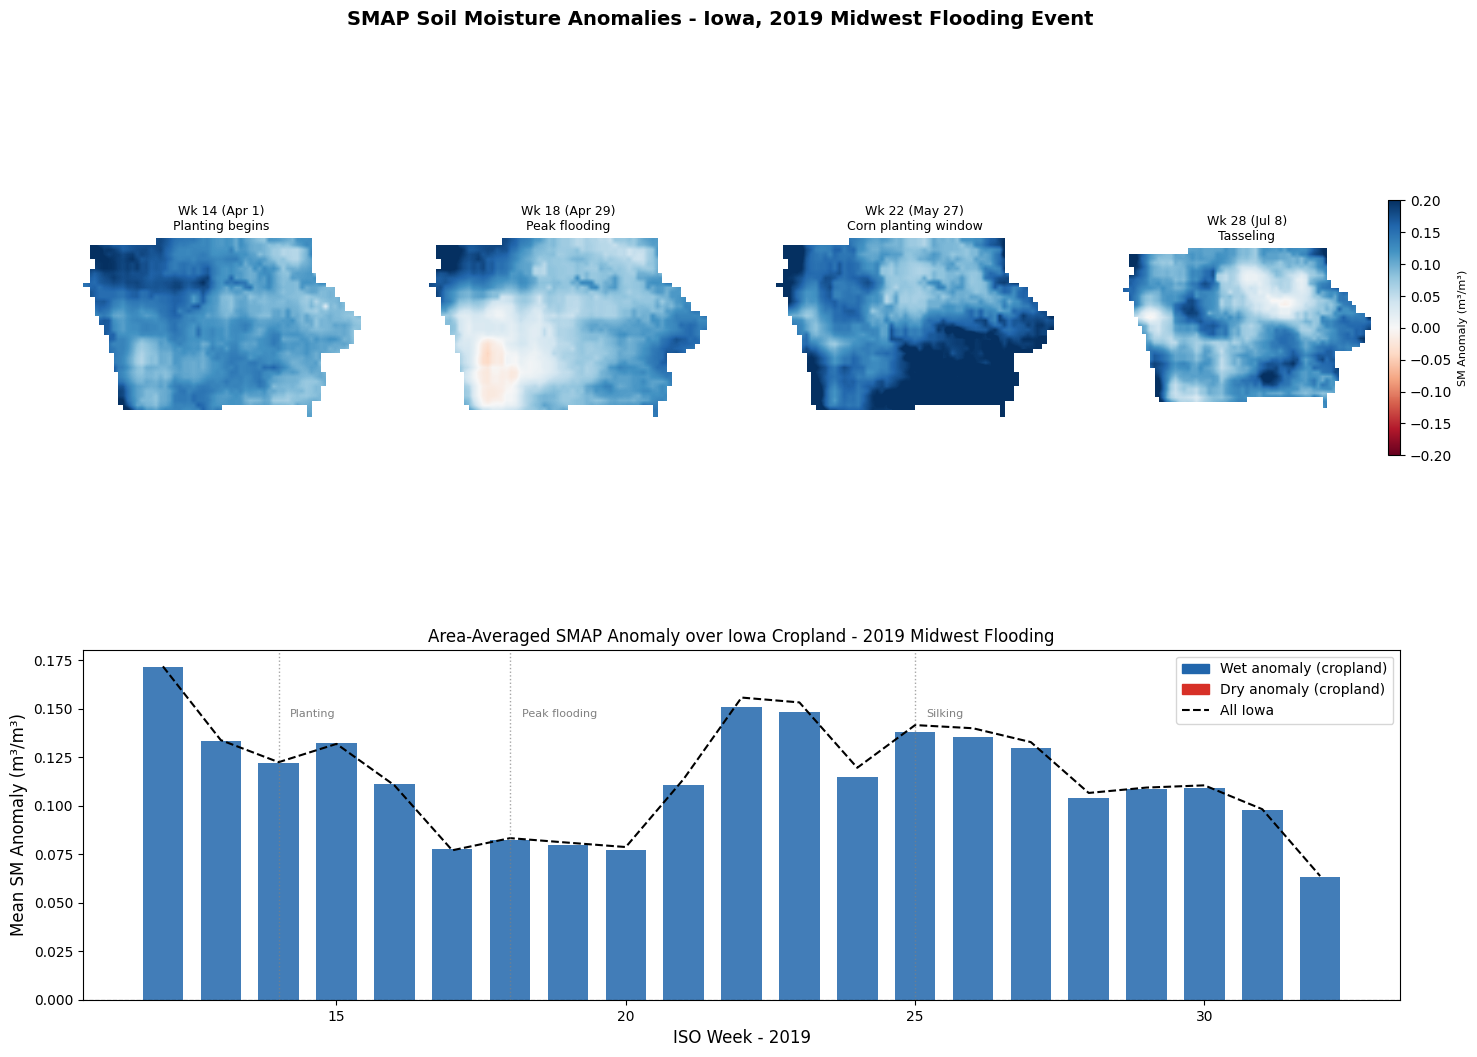

Saved: task3_smap_anomaly.png


In [42]:
# T3.4: Spatial maps + time series 
fig = plt.figure(figsize=(17, 11))
gs  = GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.25)

key_wks  = [14, 18, 22, 28]
key_lbls = ["Wk 14 (Apr 1)\nPlanting begins",
            "Wk 18 (Apr 29)\nPeak flooding",
            "Wk 22 (May 27)\nCorn planting window",
            "Wk 28 (Jul 8)\nTasseling"]

vmax = 0.20
cmap_a = plt.cm.RdBu   # blue = wet, red = dry
norm_a = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for col, (wk, lbl) in enumerate(zip(key_wks, key_lbls)):
    ax = fig.add_subplot(gs[0, col])
    if wk in anom_stack:
        im = ax.imshow(anom_stack[wk], cmap=cmap_a, norm=norm_a, interpolation="bilinear")
        if col == 3:
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.06)
            cbar.set_label("SM Anomaly (m³/m³)", fontsize=8)
    else:
        ax.text(0.5, 0.5, f"Week {wk}\nn/a", ha="center", va="center",
                transform=ax.transAxes)
    ax.set_title(lbl, fontsize=9)
    ax.axis("off")

ax_ts = fig.add_subplot(gs[1, :])
ax_ts.axhline(0, color="black", lw=0.8, ls="--")

for _, row in df_smap.iterrows():
    c = "#2166ac" if row["cropland"] >= 0 else "#d73027"
    ax_ts.bar(row["week"], row["cropland"], color=c, alpha=0.85, width=0.7)

ax_ts.plot(df_smap["week"], df_smap["all_iowa"], "k--", lw=1.5, label="All Iowa")

for wk_a, txt_a in [(14,"Planting"), (18,"Peak flooding"), (25,"Silking")]:
    ax_ts.axvline(wk_a, color="gray", ls=":", lw=1, alpha=0.7)
    ax_ts.text(wk_a + 0.2, df_smap["cropland"].max() * 0.85, txt_a, fontsize=8, color="gray")

ax_ts.set_xlabel("ISO Week - 2019", fontsize=12)
ax_ts.set_ylabel("Mean SM Anomaly (m³/m³)", fontsize=12)
ax_ts.set_title("Area-Averaged SMAP Anomaly over Iowa Cropland - 2019 Midwest Flooding", fontsize=12)
ax_ts.legend(handles=[
    mpatches.Patch(color="#2166ac", label="Wet anomaly (cropland)"),
    mpatches.Patch(color="#d73027", label="Dry anomaly (cropland)"),
    plt.Line2D([0],[0], color="k", ls="--", label="All Iowa"),
], fontsize=10)

fig.suptitle("SMAP Soil Moisture Anomalies - Iowa, 2019 Midwest Flooding Event",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("task3_smap_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task3_smap_anomaly.png")

---

## 5. Task 4 — Crop Mapping Prediction Model

Train a machine learning model to **predict crop type** for at minimum three classes: **corn**, **soybean**, and a third class (e.g., winter wheat or other/non-crop). Use multi-year CDL data as both the feature source and training labels; NDVI and SMAP may optionally be incorporated. Your analysis should:

- Construct a feature matrix from CDL-derived spatial and temporal features (e.g., historical crop type sequences, neighborhood composition, transition frequencies), optionally augmented with NDVI or SMAP statistics
- Train on CDL labels from prior years (e.g., 2013–2022) and validate on a held-out year (e.g., 2023)
- Report classification performance using overall accuracy, per-class F1 score, and a confusion matrix

**Expected output:** A trained, reproducible classification pipeline; evaluation metrics; a spatial map of predicted crop types for the test year; and a brief discussion of model limitations and generalizability.

> **Tip:** You can use the CropSmart WMS/WPS services to access CDL, NDVI, and SMAP layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [21]:
# Task 4 — Your code here
# T4.1: Build NDVI phenology feature rasters (2022) 
FEAT_YEAR  = 2022
FEAT_WEEKS = list(range(14, 44))
ndvi22_paths = {}

def _fetch22(wk):
    layer = ndvi_layer(FEAT_YEAR, wk)
    dest  = CACHE / "ndvi" / f"ndvi_{FEAT_YEAR}_{wk:02d}.tif"
    return wk, wps_get_tif(layer, dest)

print(f"Downloading NDVI 2022 ({len(FEAT_WEEKS)} weeks)...")
with ThreadPoolExecutor(max_workers=4) as ex:
    futs = {ex.submit(_fetch22, wk): wk for wk in FEAT_WEEKS}
    for f in tqdm(as_completed(futs), total=len(futs), desc="NDVI 2022"):
        wk, p = f.result()
        if p:
            ndvi22_paths[wk] = p

wks22 = sorted(ndvi22_paths.keys())
print(f"Downloaded: {len(wks22)} weeks")

# Stack into cube (n_weeks, H_ndvi, W_ndvi)
ndvi_cube = []
for wk in wks22:
    arr, _, _ = read_tif(ndvi22_paths[wk])
    # arr = arr * NDVI_SCALE
    arr = (arr - 100.0) / 100.0
    # arr[(arr < -0.2) | (arr > 1.0)] = np.nan
    arr[(arr < 0.0 ) | (arr > 1.0)] = np.nan
    ndvi_cube.append(arr)
ndvi_cube = np.stack(ndvi_cube, axis=0)

# Derive phenological features — safe against all-NaN pixels
with np.errstate(all="ignore"):
    peak_ndvi = np.nanmax(ndvi_cube, axis=0)  # NaN where all weeks NaN

    # nanargmax crashes on all-NaN slices - use a safe wrapper
    valid_pixels = ~np.isnan(peak_ndvi)  # pixels with at least one valid week

    peak_idx = np.zeros(peak_ndvi.shape, dtype=int)
    peak_idx[valid_pixels] = np.nanargmax(
        ndvi_cube[:, valid_pixels], axis=0
    )
    peak_week_arr = np.where(valid_pixels,
                             np.array(wks22)[peak_idx],
                             np.nan).astype(np.float32)

    ndvi_integral = (np.nansum(ndvi_cube, axis=0) * 7).astype(np.float32)

    above = ndvi_cube > 0.4
    greenup_idx = np.argmax(above, axis=0)
    greenup_arr = np.where(above.any(axis=0),
                           np.array(wks22)[greenup_idx],
                           np.nan).astype(np.float32)

print(f"NDVI cube: {ndvi_cube.shape}, mean peak NDVI: {np.nanmean(peak_ndvi):.3f}")
print(f"Valid pixels: {valid_pixels.sum():,} / {valid_pixels.size:,}")

NDVI 2022: 100%|██████████| 30/30 [00:02<00:00, 10.76it/s]

  [DL] ndvi_2022_42.tif: Invalid URL 'bad request': No scheme supplied. Perhaps you meant https://bad request?
  [DL] ndvi_2022_43.tif: Invalid URL 'bad request': No scheme supplied. Perhaps you meant https://bad request?
  [DL] ndvi_2022_41.tif: Invalid URL 'bad request': No scheme supplied. Perhaps you meant https://bad request?
Downloaded: 27 weeks


NDVI cube: (27, 1399, 2134), mean peak NDVI: 0.951
Valid pixels: 2,331,879 / 2,985,466


In [22]:
# T4.2: Build feature matrix 
S  = 8          # spatial stride (30m × 8 = 240m sampling)
stack_strided = cdl_stack[:, ::S, ::S]
Hs, Ws = stack_strided.shape[1], stack_strided.shape[2]
N  = Hs * Ws

flat  = stack_strided.reshape(len(ROT_YEARS), N)
rot_s = rot_map[::S, ::S].ravel().astype(np.float32)

feat = {}

# CDL binary (one-hot per crop per year)
for i, yr in enumerate(ROT_YEARS):
    for code, name in [(CDL_CORN,"corn"),(CDL_SOY,"soy"),(CDL_WHEAT,"wheat")]:
        feat[f"{name}_{yr}"] = (flat[i] == code).astype(np.float32)

# Aggregate counts
feat["corn_count"]      = (flat == CDL_CORN).sum(0).astype(np.float32)
feat["soy_count"]       = (flat == CDL_SOY).sum(0).astype(np.float32)
feat["wheat_count"]     = (flat == CDL_WHEAT).sum(0).astype(np.float32)

# Alternating transitions
alt_s = np.zeros(N, dtype=np.float32)
for t in range(9):
    alt_s += (((flat[t]==CDL_CORN)&(flat[t+1]==CDL_SOY))|
              ((flat[t]==CDL_SOY) &(flat[t+1]==CDL_CORN))).astype(np.float32)
feat["alt_transitions"] = alt_s
feat["rotation_class"]  = rot_s

# Recent 3-year sequence
for i, yr in enumerate(ROT_YEARS[-3:], start=len(ROT_YEARS)-3):
    feat[f"code_{yr}"] = flat[i].astype(np.float32)

# Spatial context (3x3 neighborhood, CDL 2022)
cdl22_2d = cdl_stack[-1, ::S, ::S].astype(float)
feat["neigh_corn"] = uniform_filter((cdl22_2d==CDL_CORN).astype(float), 3).ravel().astype(np.float32)
feat["neigh_soy"]  = uniform_filter((cdl22_2d==CDL_SOY).astype(float),  3).ravel().astype(np.float32)

# NDVI phenology - resample from NDVI 250m grid to CDL 30m, then stride-sample
with rasterio.open(ref_path) as ndvi_src:
    ndvi_meta = ndvi_src.meta.copy()
    ndvi_meta.update({"dtype":"float32","nodata":-9999})

for phen_arr, phen_name in [
    (peak_ndvi,     "ndvi_peak"),
    (peak_week_arr, "ndvi_peak_week"),
    (greenup_arr,   "ndvi_greenup_week"),
    (ndvi_integral, "ndvi_integral"),
]:
    with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
        tmppath = tmp.name
    with rasterio.open(tmppath, "w", **ndvi_meta) as dst:
        data = np.nan_to_num(phen_arr, nan=-9999).astype(np.float32)
        dst.write(data, 1)
    arr_30m = resample_to(tmppath, (H, W), cdl_t21, cdl_c21, Resampling.bilinear)
    arr_30m[arr_30m == -9999] = np.nan
    feat[phen_name] = arr_30m[::S, ::S].ravel().astype(np.float32)
    os.unlink(tmppath)

X = np.column_stack(list(feat.values()))
feature_names = list(feat.keys())
print(f"Feature matrix: {X.shape}  ({len(feature_names)} features)")

Feature matrix: (3246275, 44)  (44 features)


In [23]:
# T4.3: Labels - CDL 2023 
print("Downloading CDL 2023 (test year)...")
cdl23_path = get_cdl(2023)

if cdl23_path:
    with rasterio.open(cdl23_path) as src:
        if src.shape == (H, W):
            label_arr = src.read(1).astype(np.float32)
        else:
            label_arr = resample_to(cdl23_path, (H, W), cdl_t21, cdl_c21, Resampling.nearest)
    test_year = 2023
    print(f"  CDL 2023 loaded")
else:
    print("  CDL 2023 unavailable - using CDL 2022 as fallback")
    with rasterio.open(cdl_paths[2022]) as src:
        label_arr = src.read(1).astype(np.float32)
    test_year = 2022

y_raw = label_arr[::S, ::S].ravel()
# 4-class remapping: 0=Corn, 1=Soy, 2=Winter Wheat, 3=Other
y = np.where(y_raw==CDL_CORN, 0,
    np.where(y_raw==CDL_SOY,  1,
    np.where(y_raw==CDL_WHEAT,2, 3))).astype(np.int8)

# Focus on pixels with ≥2 years of corn or soy in last 5 years
recent5 = (flat[-5:]==CDL_CORN).sum(0) + (flat[-5:]==CDL_SOY).sum(0)
focus   = (recent5 >= 2) | (y_raw == CDL_WHEAT)
valid   = (~np.isnan(X).any(axis=1)) & focus

X_v = np.nan_to_num(X[valid], nan=0.0)
y_v = y[valid]
print(f"Valid crop pixels: {X_v.shape[0]:,}")
for cid, cn in zip([0,1,2,3],["Corn","Soy","Wheat","Other"]):
    print(f"  {cn}: {(y_v==cid).sum():,}")

  CDL 2023 loaded
Valid crop pixels: 1,671,677
  Corn: 889,249
  Soy: 685,767
  Wheat: 877
  Other: 95,784


In [24]:
# T4.4: Train Random Forest 
X_tr, X_te, y_tr, y_te = train_test_split(
    X_v, y_v, test_size=0.20, random_state=42, stratify=y_v
)
print(f"Train: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    class_weight="balanced",   # handles winter wheat imbalance
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
print("Training Random Forest...")
rf.fit(X_tr, y_tr)
print(f"OOB accuracy: {rf.oob_score_:.4f}")

y_pred = rf.predict(X_te)
CLASS_NAMES = ["Corn", "Soybean", "Winter Wheat", "Other/Crop"]
oa    = accuracy_score(y_te, y_pred)
f1mac = f1_score(y_te, y_pred, average="macro")

print(f"\n{'='*45}")
print(f"Overall Accuracy (OA):  {oa:.4f}  ({oa*100:.1f}%)")
print(f"Macro F1:               {f1mac:.4f}")
print(f"{'='*45}\n")
print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

Train: 1,337,341  |  Test: 334,336
Training Random Forest...
OOB accuracy: 0.8668

Overall Accuracy (OA):  0.8670  (86.7%)
Macro F1:               0.6501

              precision    recall  f1-score   support

        Corn       0.92      0.85      0.89    177850
     Soybean       0.85      0.89      0.87    137154
Winter Wheat       0.12      0.20      0.15       175
  Other/Crop       0.60      0.82      0.69     19157

    accuracy                           0.87    334336
   macro avg       0.62      0.69      0.65    334336
weighted avg       0.88      0.87      0.87    334336



In [25]:
# !pip install skl2onnx 
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import json, pathlib

pathlib.Path("webapp").mkdir(exist_ok=True)
initial_type = [("float_input", FloatTensorType([None, len(feature_names)]))]
onnx_model = convert_sklearn(rf, initial_types=initial_type)
with open("webapp/cropsmart_rf.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())
with open("webapp/model_meta.json", "w") as f:
    json.dump({"feature_names": feature_names, "class_names": ["Corn","Soybean","Winter Wheat","Other/Crop"]}, f)
print("Exported")

Exported


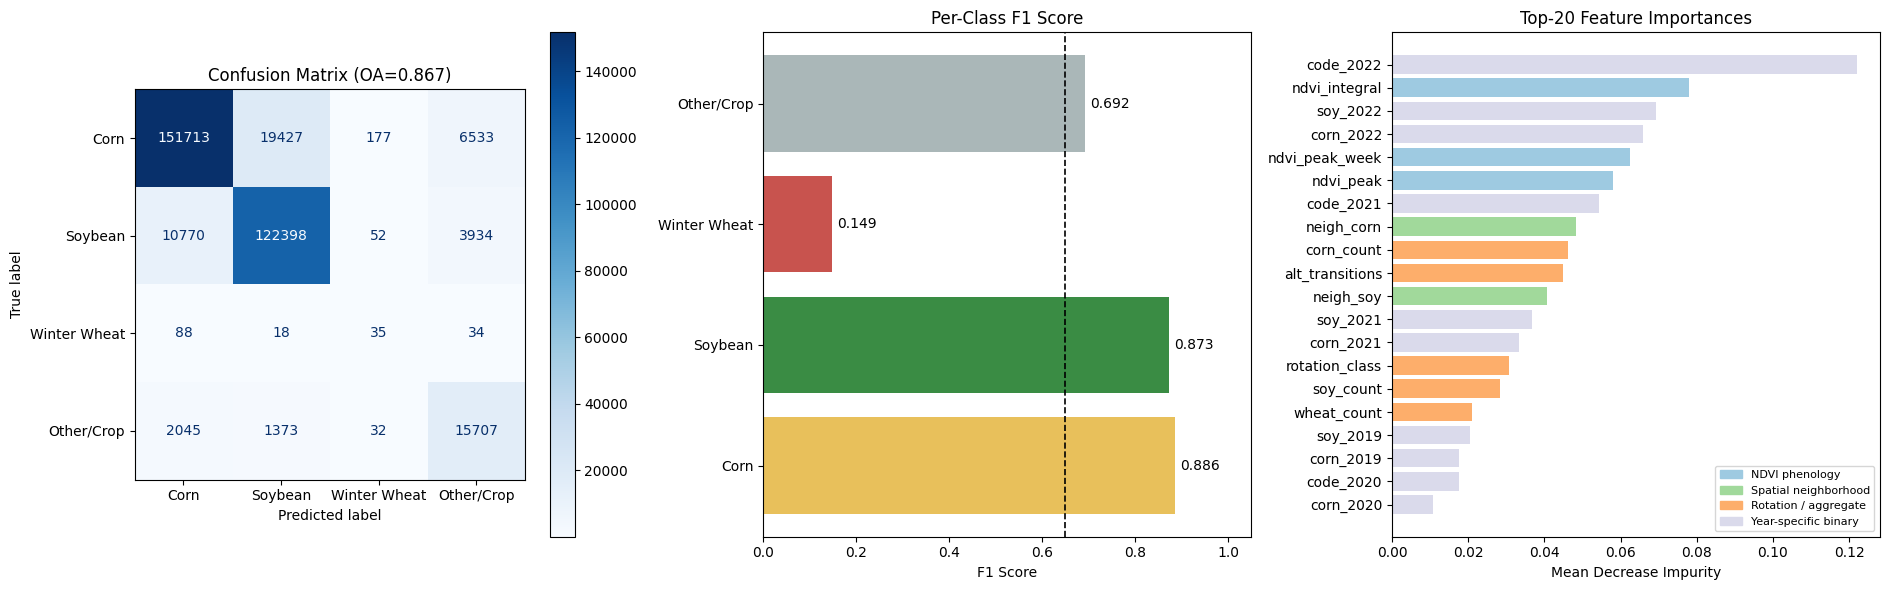

Saved: task4_evaluation.png


In [26]:
# T4.5: Evaluation plots
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=True, cmap="Blues")
axes[0].set_title(f"Confusion Matrix (OA={oa:.3f})", fontsize=12)

# Per-class F1
f1_pc = f1_score(y_te, y_pred, average=None, labels=[0,1,2,3])
clr4 = ["#e8c05b", "#3a8c44", "#c8534e", "#aab7b8"]
axes[1].barh(CLASS_NAMES, f1_pc, color=clr4)
axes[1].axvline(f1mac, ls="--", color="k", lw=1.2)
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(f1_pc):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)
axes[1].set_title("Per-Class F1 Score", fontsize=12)
axes[1].set_xlabel("F1 Score")

# Top-20 feature importances
fi = pd.DataFrame({"f": feature_names, "imp": rf.feature_importances_})
fi = fi.nlargest(20, "imp").sort_values("imp")

def fi_clr(n):
    if "ndvi" in n:  return "#9ecae1"
    if "neigh" in n: return "#a1d99b"
    if "alt" in n or "rot" in n or "count" in n: return "#fdae6b"
    return "#dadaeb"

axes[2].barh(fi["f"], fi["imp"], color=[fi_clr(n) for n in fi["f"]])
axes[2].set_title("Top-20 Feature Importances", fontsize=12)
axes[2].set_xlabel("Mean Decrease Impurity")
axes[2].legend(handles=[
    mpatches.Patch(color="#9ecae1", label="NDVI phenology"),
    mpatches.Patch(color="#a1d99b", label="Spatial neighborhood"),
    mpatches.Patch(color="#fdae6b", label="Rotation / aggregate"),
    mpatches.Patch(color="#dadaeb", label="Year-specific binary"),
], fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("task4_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task4_evaluation.png")

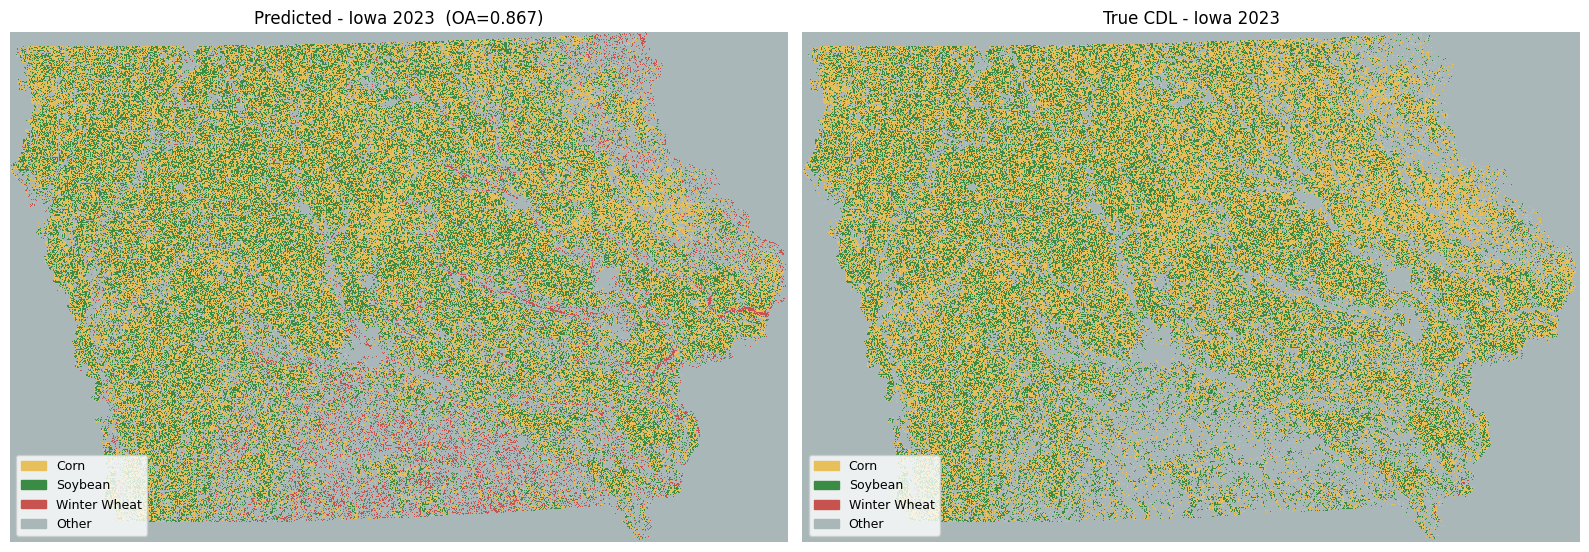

Saved: task4_prediction_map.png


In [27]:
# T4.6: Prediction map vs. true CDL 
X_all   = np.nan_to_num(X, nan=0.0)
pred_map = rf.predict(X_all).reshape(Hs, Ws)
true_map = y.reshape(Hs, Ws)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
crop_cmap = mcolors.ListedColormap(["#e8c05b","#3a8c44","#c8534e","#aab7b8"])
crop_norm = mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5,3.5], crop_cmap.N)

for ax, arr, title in [
    (axes[0], pred_map, f"Predicted - Iowa {test_year}  (OA={oa:.3f})"),
    (axes[1], true_map, f"True CDL - Iowa {test_year}"),
]:
    ax.imshow(arr, cmap=crop_cmap, norm=crop_norm, interpolation="none")
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    ax.legend(handles=[
        mpatches.Patch(color="#e8c05b", label="Corn"),
        mpatches.Patch(color="#3a8c44", label="Soybean"),
        mpatches.Patch(color="#c8534e", label="Winter Wheat"),
        mpatches.Patch(color="#aab7b8", label="Other"),
    ], loc="lower left", fontsize=9)

plt.tight_layout()
plt.savefig("task4_prediction_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task4_prediction_map.png")

In [28]:
# T4.7: Performance by rotation class (irregular vs. regular) 
rot_valid = rot_map[::S, ::S].ravel()[valid]
# _, _, rot_te, _ = train_test_split(rot_valid, rot_valid, test_size=0.20, random_state=42)
_, rot_te, _, _ = train_test_split(rot_valid, rot_valid, test_size=0.20, random_state=42)

rows = []
for code, label in [(1,"Regular Corn-Soy"),(2,"Continuous Corn"),
                    (3,"Continuous Soy"),(4,"Irregular / Other")]:
    m = rot_te == code
    if m.sum() < 20:
        continue
    rows.append({
        "Rotation Class": label,
        "N test pixels":  int(m.sum()),
        "OA":    round(accuracy_score(y_te[m], y_pred[m]), 3),
        "F1":    round(f1_score(y_te[m], y_pred[m], average="macro", zero_division=0), 3),
    })

print(pd.DataFrame(rows).to_string(index=False))

   Rotation Class  N test pixels    OA    F1
 Regular Corn-Soy         215540 0.866 0.646
  Continuous Corn          36630 0.866 0.647
   Continuous Soy            750 0.851 0.805
Irregular / Other          81416 0.869 0.661
